# 1. Exploración de Datos — Predicting Electric Vehicle Purchases

Primer recorrido por el dataset del episodio, antes de modelar. El objetivo es contestar tres cosas:

- **¿Dónde está la señal?** Qué variables discriminan de verdad y cuáles son ruido.
- **¿Qué forma tiene?** Si las relaciones son monótonas y aproximadamente lineales en log-odds, un
  modelo lineal alcanza; si no, hay que construir features o pasar a árboles.
- **¿Hay interacciones?** Efectos que cambian según el nivel de otra variable — lo único que un logit
  aditivo no puede capturar por sí solo.

**Métrica oficial de la competencia:** ROC AUC.
**Dataset:** Playground Series S6E9

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import roc_auc_score
import warnings
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (15, 6)
plt.rcParams["figure.dpi"] = 100

SEED = 42

In [2]:
train = pd.read_csv("../data/train.csv")
test  = pd.read_csv("../data/test.csv")

TARGET = "Will_Buy_EV"

numericas = ["Age", "Annual_Income_USD", "Daily_Commute_km", "Number_of_Cars_Owned",
             "Charging_Stations_Near_Home", "Charging_Stations_Near_Work",
             "Environmental_Concern_Level"]
categoricas = ["Gender", "City_Type", "Current_Car_Type",
               "Home_Charging_Possible", "Subsidy_Available", "Range_Anxiety_Level"]

# Version binaria del target para promedios y AUC
train["y"] = (train[TARGET] == "Yes").astype(int)

print(f"Train: {train.shape[0]:,} filas x {train.shape[1] - 1} columnas")
print(f"Test:  {test.shape[0]:,} filas x {test.shape[1]} columnas")
print(f"Numericas: {len(numericas)} | Categoricas: {len(categoricas)}")

Train: 668,665 filas x 15 columnas
Test:  286,571 filas x 14 columnas
Numericas: 7 | Categoricas: 6


## 2. Visión General del Dataset

In [3]:
train.head()

,id,Age,Annual_Income_USD,Daily_Commute_km,Number_of_Cars_Owned,Charging_Stations_Near_Home,Charging_Stations_Near_Work,Environmental_Concern_Level,Gender,City_Type,Current_Car_Type,Home_Charging_Possible,Subsidy_Available,Range_Anxiety_Level,Will_Buy_EV,y
0,0,66,92887.0,23.4,2,3,7,1.0,Male,Suburban,Sedan,Yes,No,Low,No,0
1,1,38,30000.0,5.0,1,2,2,4.0,Male,Rural,SUV,Yes,No,Low,No,0
2,2,26,94389.0,36.8,1,8,15,5.0,Female,Urban,Sedan,No,Yes,Low,Yes,1
3,3,66,73580.0,23.7,2,6,9,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,0
4,4,54,57898.0,50.8,1,2,3,3.0,Male,Suburban,Hatchback,Yes,No,Low,No,0


In [4]:
train.drop(columns='y').info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 668665 entries, 0 to 668664
Data columns (total 15 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   id                           668665 non-null  int64  
 1   Age                          668665 non-null  int64  
 2   Annual_Income_USD            668665 non-null  float64
 3   Daily_Commute_km             668665 non-null  float64
 4   Number_of_Cars_Owned         668665 non-null  int64  
 5   Charging_Stations_Near_Home  668665 non-null  int64  
 6   Charging_Stations_Near_Work  668665 non-null  int64  
 7   Environmental_Concern_Level  668665 non-null  float64
 8   Gender                       668665 non-null  object 
 9   City_Type                    668665 non-null  object 
 10  Current_Car_Type             668665 non-null  object 
 11  Home_Charging_Possible       668665 non-null  object 
 12  Subsidy_Available            668665 non-null  object 
 13 

In [5]:
train[numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
Age,668665.0,47.039171,12.875448,25.0,36.0,47.0,58.0,69.0
Annual_Income_USD,668665.0,84769.266989,28648.029042,30000.0,67376.0,84880.0,102753.0,188549.0
Daily_Commute_km,668665.0,32.158298,18.730474,5.0,17.2,33.6,47.4,98.7
Number_of_Cars_Owned,668665.0,1.712626,0.729275,1.0,1.0,2.0,2.0,4.0
Charging_Stations_Near_Home,668665.0,4.960408,3.926843,0.0,2.0,4.0,7.0,14.0
Charging_Stations_Near_Work,668665.0,7.176314,5.186627,0.0,3.0,6.0,10.0,19.0
Environmental_Concern_Level,668665.0,2.935477,1.429119,1.0,2.0,3.0,4.0,5.0


In [6]:
feats = numericas + categoricas

print("Valores nulos por columna (solo las features, que son las columnas en comun):")
nulos = pd.DataFrame({"train": train[feats].isna().sum(), "test": test[feats].isna().sum()})
print(nulos.to_string())
print(f"\nFilas duplicadas (ignorando id y target): {train.duplicated(subset=feats).sum():,}")
print(f"ids unicos en train: {train['id'].is_unique} | en test: {test['id'].is_unique}")

Valores nulos por columna (solo las features, que son las columnas en comun):


                             train  test
Age                              0     0
Annual_Income_USD                0     0
Daily_Commute_km                 0     0
Number_of_Cars_Owned             0     0
Charging_Stations_Near_Home      0     0
Charging_Stations_Near_Work      0     0
Environmental_Concern_Level      0     0
Gender                           0     0
City_Type                        0     0
Current_Car_Type                 0     0
Home_Charging_Possible           0     0
Subsidy_Available                0     0
Range_Anxiety_Level              0     0



Filas duplicadas (ignorando id y target): 0
ids unicos en train: True | en test: True


No hay un solo nulo ni filas repetidas: el preprocesamiento no va a necesitar imputación, y todo el
esfuerzo puede ir a entender la estructura de la señal.

## 3. Distribución del Target

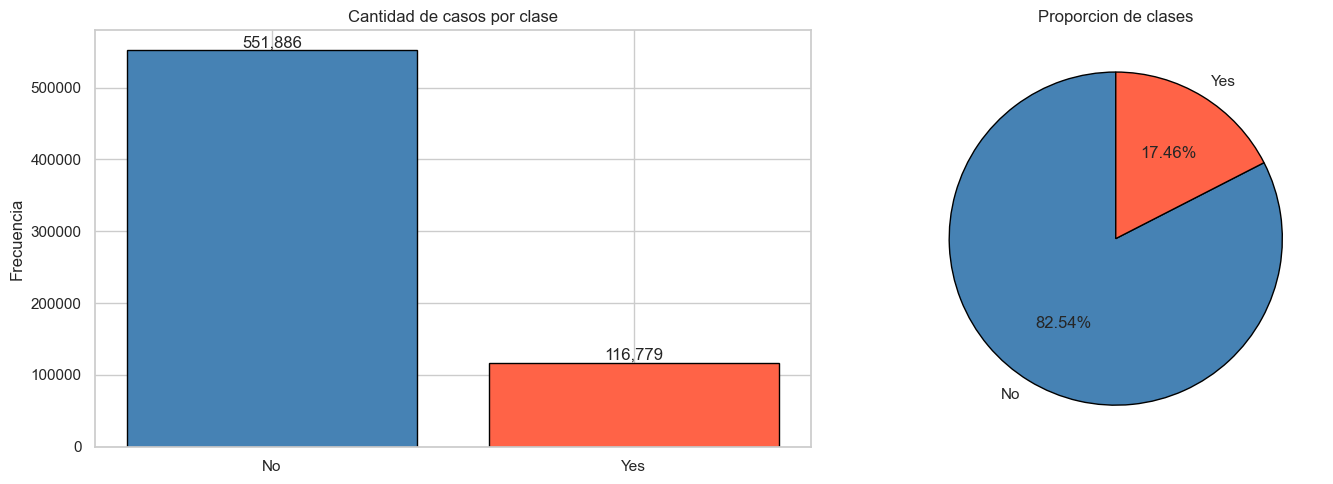

Tasa base (Will_Buy_EV = Yes): 17.4645%
Ratio de desbalance: 1 positivo cada 4.73 negativos


In [7]:
counts = train[TARGET].value_counts()
tasa_base = train["y"].mean()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
axes[0].bar(counts.index, counts.values, color=["steelblue", "tomato"], edgecolor="black")
axes[0].set_title("Cantidad de casos por clase")
axes[0].set_ylabel("Frecuencia")
for i, v in enumerate(counts.values):
    axes[0].text(i, v, f"{v:,}", ha="center", va="bottom")

axes[1].pie(counts.values, labels=counts.index, autopct="%1.2f%%",
            colors=["steelblue", "tomato"], startangle=90,
            wedgeprops={"edgecolor": "black"})
axes[1].set_title("Proporcion de clases")
plt.tight_layout()
plt.show()

print(f"Tasa base (Will_Buy_EV = Yes): {tasa_base:.4%}")
print(f"Ratio de desbalance: 1 positivo cada {(1 - tasa_base) / tasa_base:.2f} negativos")

Desbalance moderado (17,46 % de positivos). Con ROC AUC como métrica no hace falta rebalancear: el
AUC es invariante a la prevalencia y sólo mide el ordenamiento de las probabilidades.

## 4. Variables Numéricas — Distribuciones

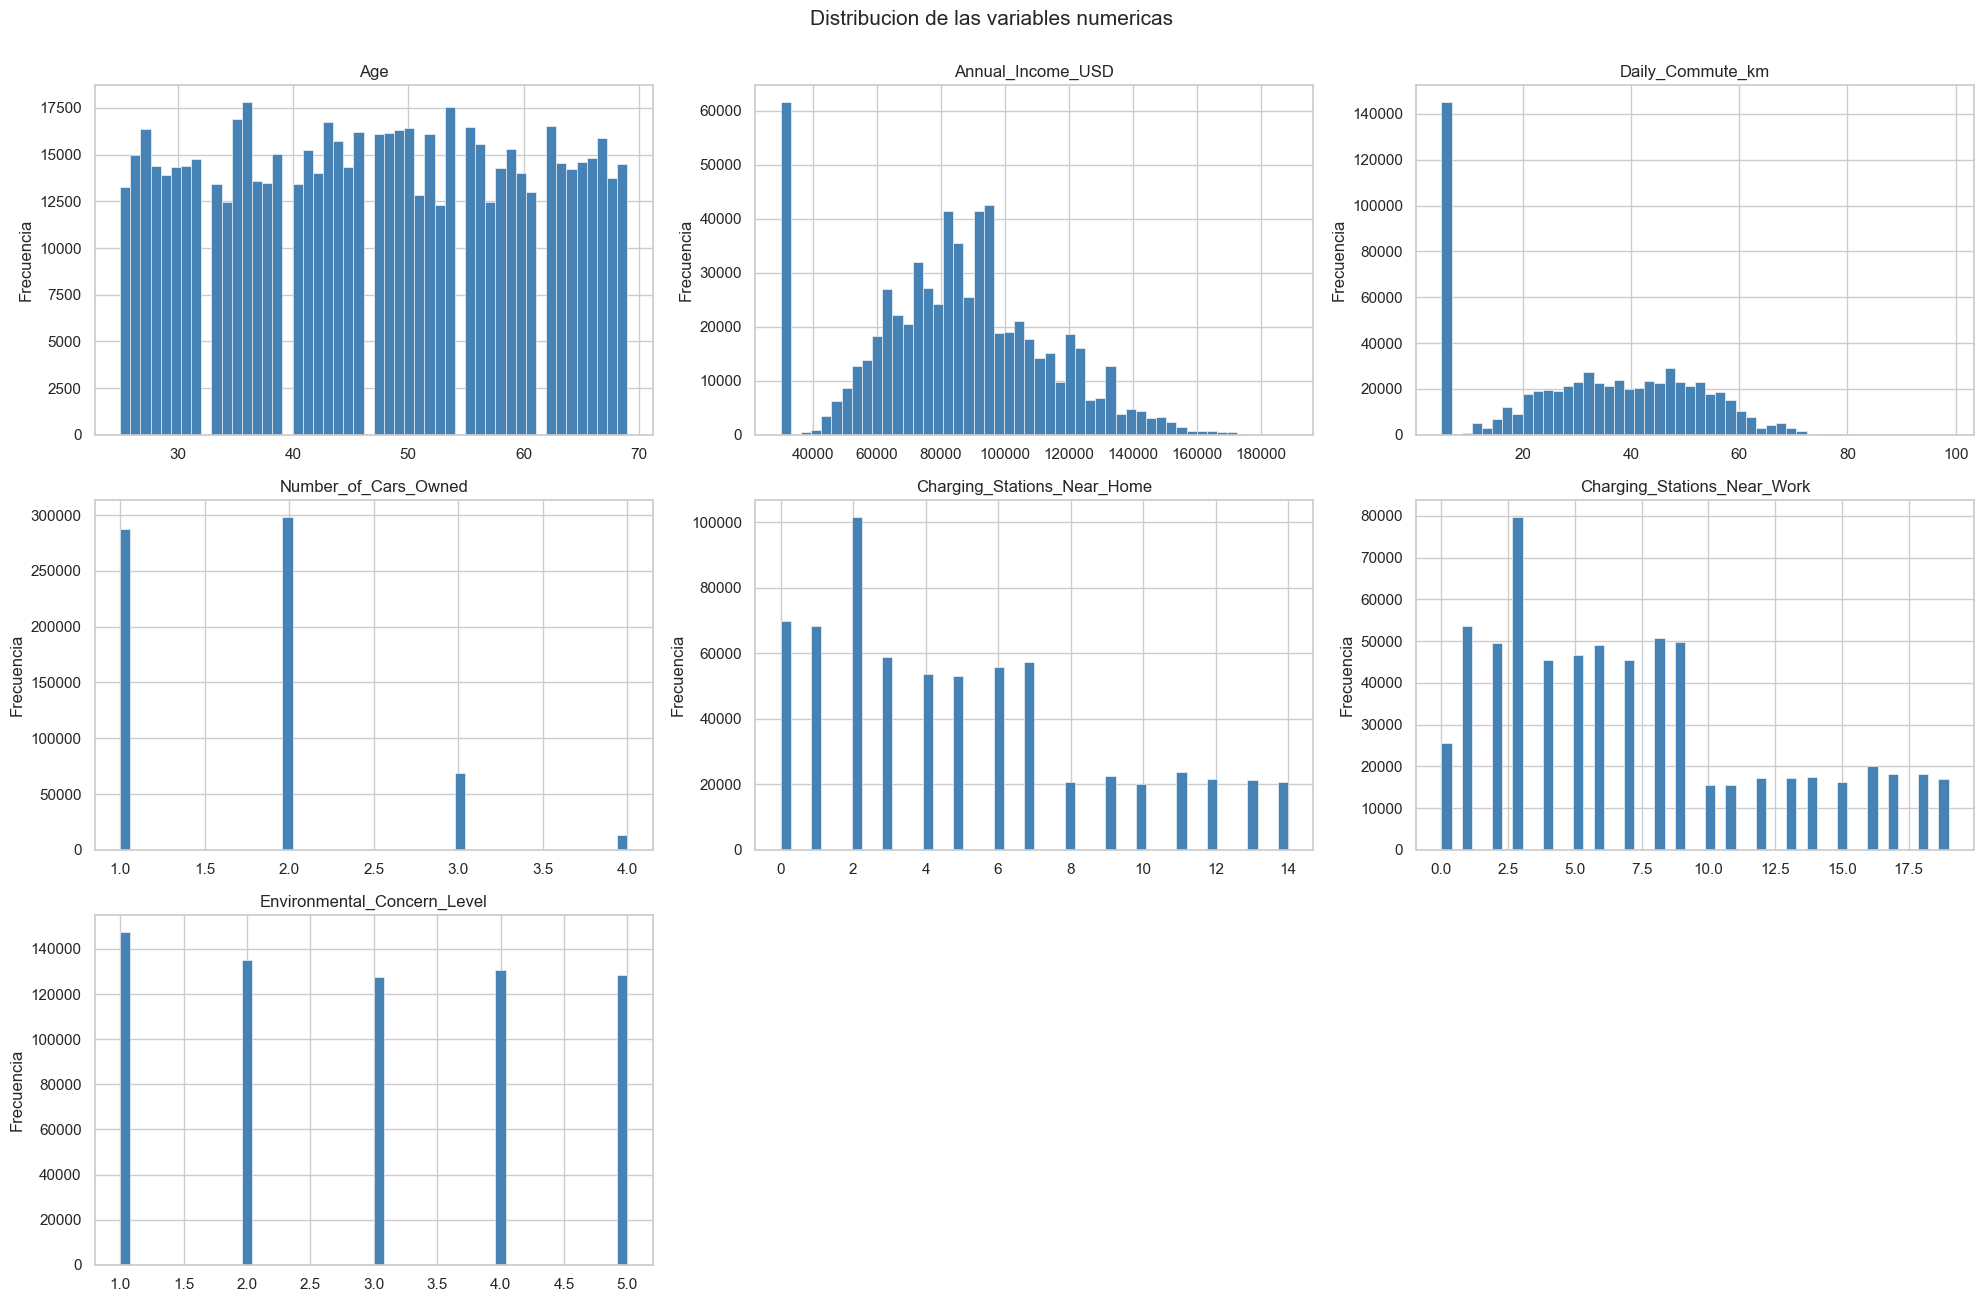

In [8]:
fig, axes = plt.subplots(3, 3, figsize=(20, 13))
for ax, col in zip(axes.ravel(), numericas):
    ax.hist(train[col], bins=50, color="steelblue", edgecolor="white", linewidth=0.4)
    ax.set_title(col)
    ax.set_ylabel("Frecuencia")
for ax in axes.ravel()[len(numericas):]:
    ax.set_visible(False)
plt.suptitle("Distribucion de las variables numericas", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

`Annual_Income_USD` es la única con asimetría marcada (cola derecha larga) — candidata a una
transformación logarítmica. `Age`, `Daily_Commute_km` y los conteos de estaciones son prácticamente
uniformes, y `Environmental_Concern_Level` es un ordinal de 1 a 5 con niveles casi equiprobables.

## 5. Variables Numéricas vs Target

En vez de comparar medias, se mira la **tasa de compra por decil** de cada variable: muestra a la vez
la fuerza del efecto y su forma (monótona, plana o con curvatura).

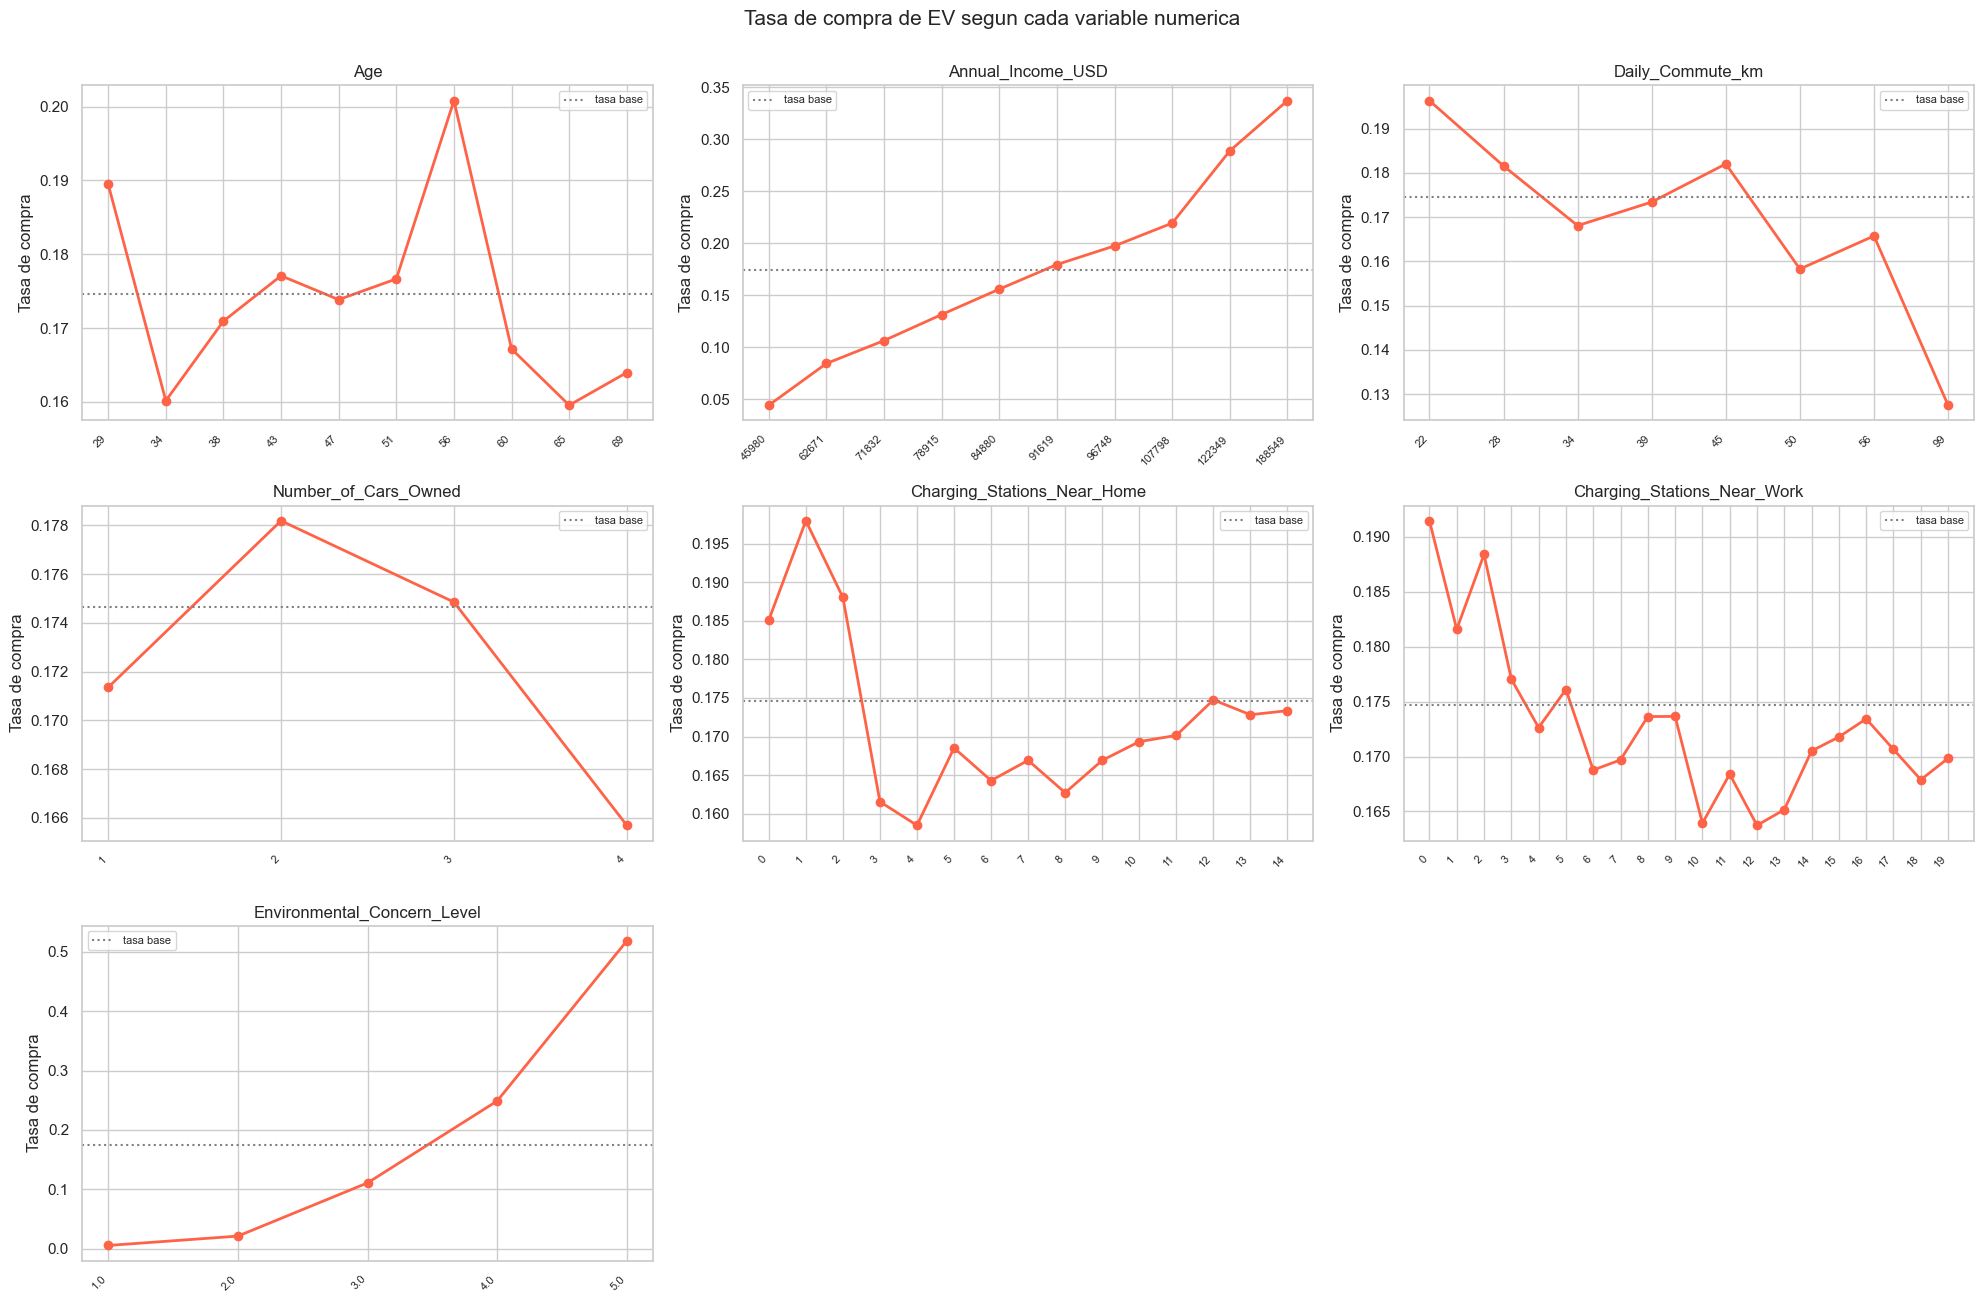

In [9]:
fig, axes = plt.subplots(3, 3, figsize=(20, 13))
for ax, col in zip(axes.ravel(), numericas):
    if train[col].nunique() <= 20:
        g = train.groupby(col)["y"].mean()
        etiquetas = [str(v) for v in g.index]
    else:
        bins = pd.qcut(train[col], 10, duplicates="drop")
        g = train.groupby(bins, observed=True)["y"].mean()
        etiquetas = [f"{iv.right:.0f}" for iv in g.index]
    ax.plot(range(len(g)), g.values, marker="o", color="tomato", lw=2)
    ax.axhline(tasa_base, color="gray", ls=":", lw=1.5, label="tasa base")
    ax.set_xticks(range(len(g)))
    ax.set_xticklabels(etiquetas, rotation=45, ha="right", fontsize=8)
    ax.set_title(col)
    ax.set_ylabel("Tasa de compra")
    ax.legend(fontsize=8)
for ax in axes.ravel()[len(numericas):]:
    ax.set_visible(False)
plt.suptitle("Tasa de compra de EV segun cada variable numerica", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

In [10]:
# La forma importa: si el log-odds es lineal en la variable, un logit la modela sin transformarla.
def tabla_log_odds(col, bins=None):
    grupo = train.groupby(bins if bins is not None else col, observed=True)["y"]
    t = pd.DataFrame({"tasa": grupo.mean(), "n": grupo.size()})
    t["log_odds"] = np.log(t["tasa"] / (1 - t["tasa"]))
    t["delta"] = t["log_odds"].diff()
    return t.round(4)

print("Environmental_Concern_Level")
print(tabla_log_odds("Environmental_Concern_Level").to_string())
print("\nAnnual_Income_USD (deciles)")
print(tabla_log_odds("Annual_Income_USD",
                     pd.qcut(train["Annual_Income_USD"], 10, labels=False)).to_string())

Environmental_Concern_Level
                               tasa       n  log_odds   delta
Environmental_Concern_Level                                  
1.0                          0.0057  147476   -5.1695     NaN
2.0                          0.0214  135133   -3.8237  1.3458
3.0                          0.1109  127351   -2.0814  1.7424
4.0                          0.2488  130469   -1.1048  0.9766
5.0                          0.5183  128236    0.0732  1.1779

Annual_Income_USD (deciles)


                     tasa      n  log_odds   delta
Annual_Income_USD                                 
0                  0.0445  66942   -3.0671     NaN
1                  0.0846  66861   -2.3815  0.6856
2                  0.1066  66834   -2.1257  0.2558
3                  0.1316  66844   -1.8864  0.2393
4                  0.1561  66977   -1.6877  0.1988
5                  0.1797  67013   -1.5181  0.1696
6                  0.1977  66616   -1.4009  0.1172
7                  0.2196  66854   -1.2683  0.1326
8                  0.2890  66970   -0.9001  0.3682
9                  0.3373  66754   -0.6753  0.2248


`Environmental_Concern_Level` se comporta muy bien para un modelo lineal: los saltos de log-odds
entre niveles consecutivos rondan 1,0-1,7, sin cambios de régimen. Un logit la aprovecha casi por
completo sin discretizarla.

`Annual_Income_USD` es monótona pero **no uniforme en log-odds**: el salto del primer al segundo decil
(+0,69) triplica a los del medio (~0,15-0,25). La curva es más empinada abajo, que es justo lo que
comprime una transformación logarítmica — motivo para probar `log(ingreso)` en el modelo.

## 6. Variables Categóricas vs Target

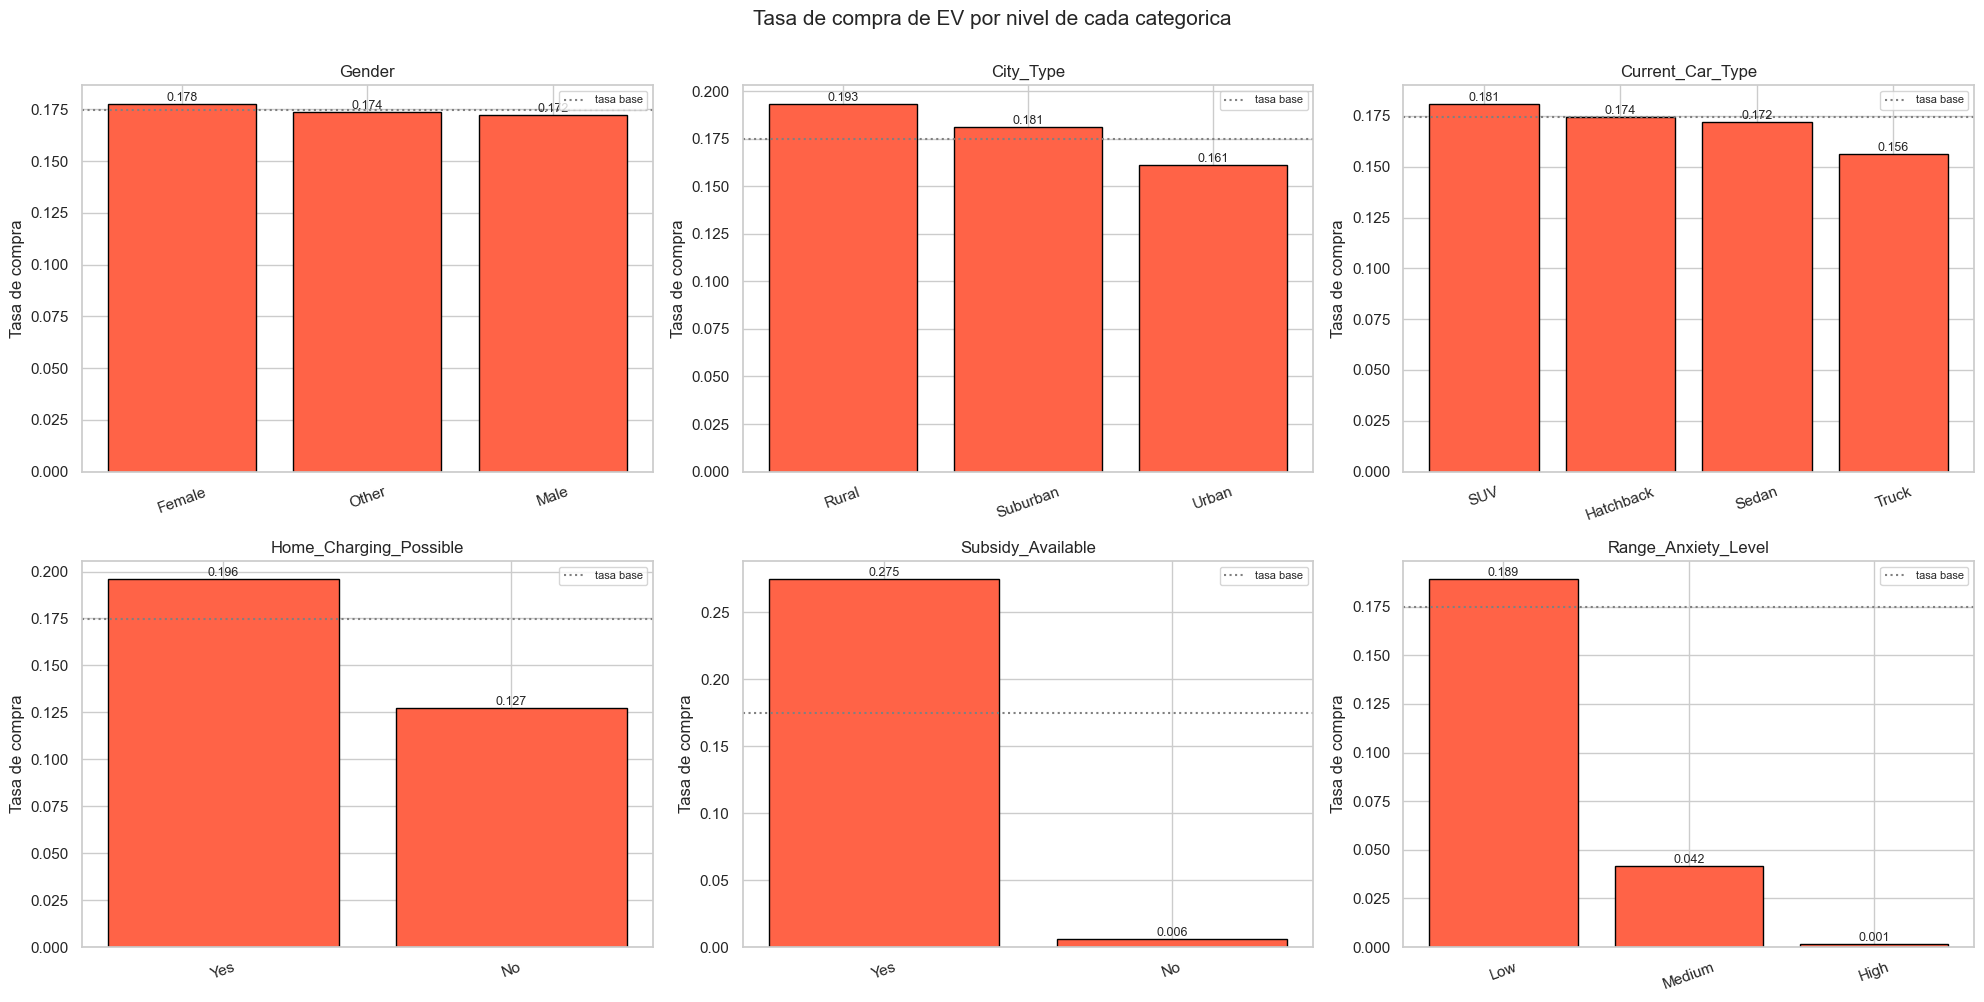

Gender                     spread = 0.0054   niveles = 3
City_Type                  spread = 0.0323   niveles = 3


Current_Car_Type           spread = 0.0245   niveles = 4
Home_Charging_Possible     spread = 0.0687   niveles = 2


Subsidy_Available          spread = 0.2689   niveles = 2
Range_Anxiety_Level        spread = 0.1877   niveles = 3


In [11]:
fig, axes = plt.subplots(2, 3, figsize=(20, 10))
for ax, col in zip(axes.ravel(), categoricas):
    g = train.groupby(col)["y"].mean().sort_values(ascending=False)
    ax.bar(g.index.astype(str), g.values, color="tomato", edgecolor="black")
    ax.axhline(tasa_base, color="gray", ls=":", lw=1.5, label="tasa base")
    ax.set_title(col)
    ax.set_ylabel("Tasa de compra")
    ax.tick_params(axis="x", rotation=20)
    ax.legend(fontsize=8)
    for i, v in enumerate(g.values):
        ax.text(i, v, f"{v:.3f}", ha="center", va="bottom", fontsize=9)
plt.suptitle("Tasa de compra de EV por nivel de cada categorica", fontsize=15, y=1.00)
plt.tight_layout()
plt.show()

for col in categoricas:
    g = train.groupby(col)["y"].agg(["mean", "size"])
    spread = g["mean"].max() - g["mean"].min()
    print(f"{col:26s} spread = {spread:.4f}   niveles = {len(g)}")

`Subsidy_Available` y `Range_Anxiety_Level` son categóricas casi determinantes: sin subsidio la tasa
cae a 0,58 % y con ansiedad de autonomía alta a 0,14 %, contra una base de 17,46 %. En el otro
extremo, `Gender` y `Current_Car_Type` apenas se mueven de la tasa base — son ruido.

## 7. Poder Discriminante — AUC Univariado

El AUC de cada variable usada **sola** como score. Es directamente comparable con la métrica de la
competencia y deja claro cuánto tiene que agregar el modelo por encima de la mejor variable suelta.

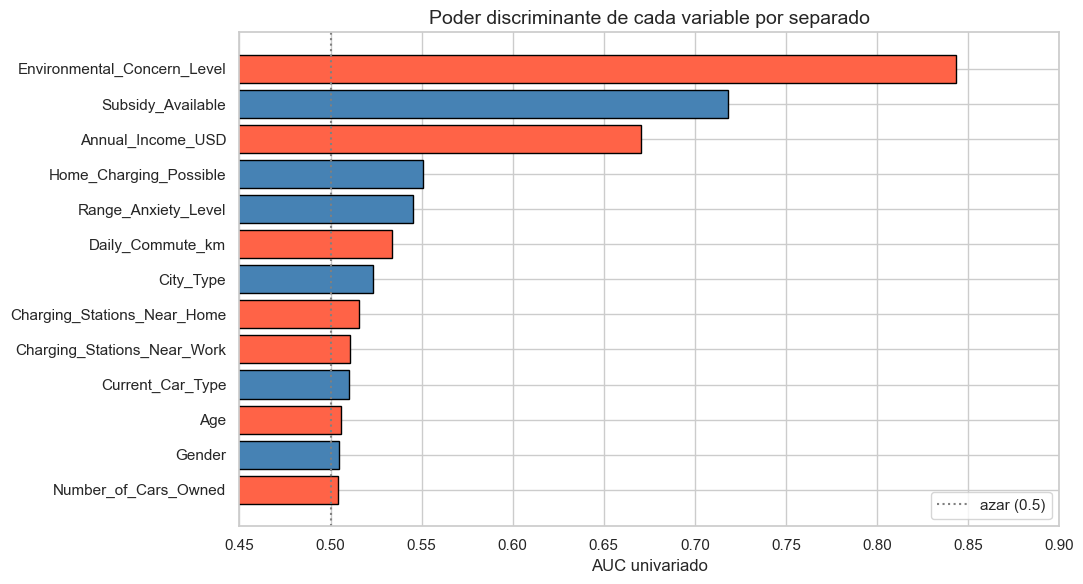

                   variable       tipo    auc signo
Environmental_Concern_Level   numerica 0.8435     +
          Subsidy_Available categorica 0.7179     +
          Annual_Income_USD   numerica 0.6704     +
     Home_Charging_Possible categorica 0.5508     +
        Range_Anxiety_Level categorica 0.5451     +
           Daily_Commute_km   numerica 0.5338     -
                  City_Type categorica 0.5234     +
Charging_Stations_Near_Home   numerica 0.5159     -
Charging_Stations_Near_Work   numerica 0.5106     -
           Current_Car_Type categorica 0.5104     +
                        Age   numerica 0.5055     -
                     Gender categorica 0.5046     +
       Number_of_Cars_Owned   numerica 0.5039     +


In [12]:
filas = []
for col in numericas:
    auc = roc_auc_score(train["y"], train[col])
    filas.append({"variable": col, "tipo": "numerica",
                  "auc": max(auc, 1 - auc), "signo": "+" if auc >= 0.5 else "-"})
for col in categoricas:
    # Se usa la tasa de target por nivel como score (equivale a ordenar por el nivel)
    score = train[col].map(train.groupby(col)["y"].mean())
    filas.append({"variable": col, "tipo": "categorica",
                  "auc": roc_auc_score(train["y"], score), "signo": "+"})

poder = pd.DataFrame(filas).sort_values("auc", ascending=False).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(11, 6))
colores = ["tomato" if t == "numerica" else "steelblue" for t in poder["tipo"]]
ax.barh(poder["variable"][::-1], poder["auc"][::-1], color=colores[::-1], edgecolor="black")
ax.axvline(0.5, color="gray", ls=":", lw=1.5, label="azar (0.5)")
ax.set_xlabel("AUC univariado")
ax.set_title("Poder discriminante de cada variable por separado", fontsize=14)
ax.set_xlim(0.45, 0.9)
ax.legend()
plt.tight_layout()
plt.show()

print(poder.round(4).to_string(index=False))

La señal está **muy concentrada**: `Environmental_Concern_Level` sola llega a 0,84 de AUC, y con
`Subsidy_Available` y `Range_Anxiety_Level` detrás. `Age`, `Number_of_Cars_Owned` y `Gender` están
pegadas a 0,50 — no aportan nada por sí solas (podrían aportar en interacción, se revisa abajo).

Ojo con la lectura de las categóricas: el AUC calculado mapeando cada nivel a su tasa de target usa
información del target, así que sobreestima un poco. Sirve para ordenar variables, no como estimación
honesta de performance.

## 8. Interacciones

Un logit aditivo asume que el efecto de cada variable es el mismo en todo el resto del espacio. Acá se
chequea dónde esa hipótesis falla — que es exactamente donde conviene construir features cruzadas.

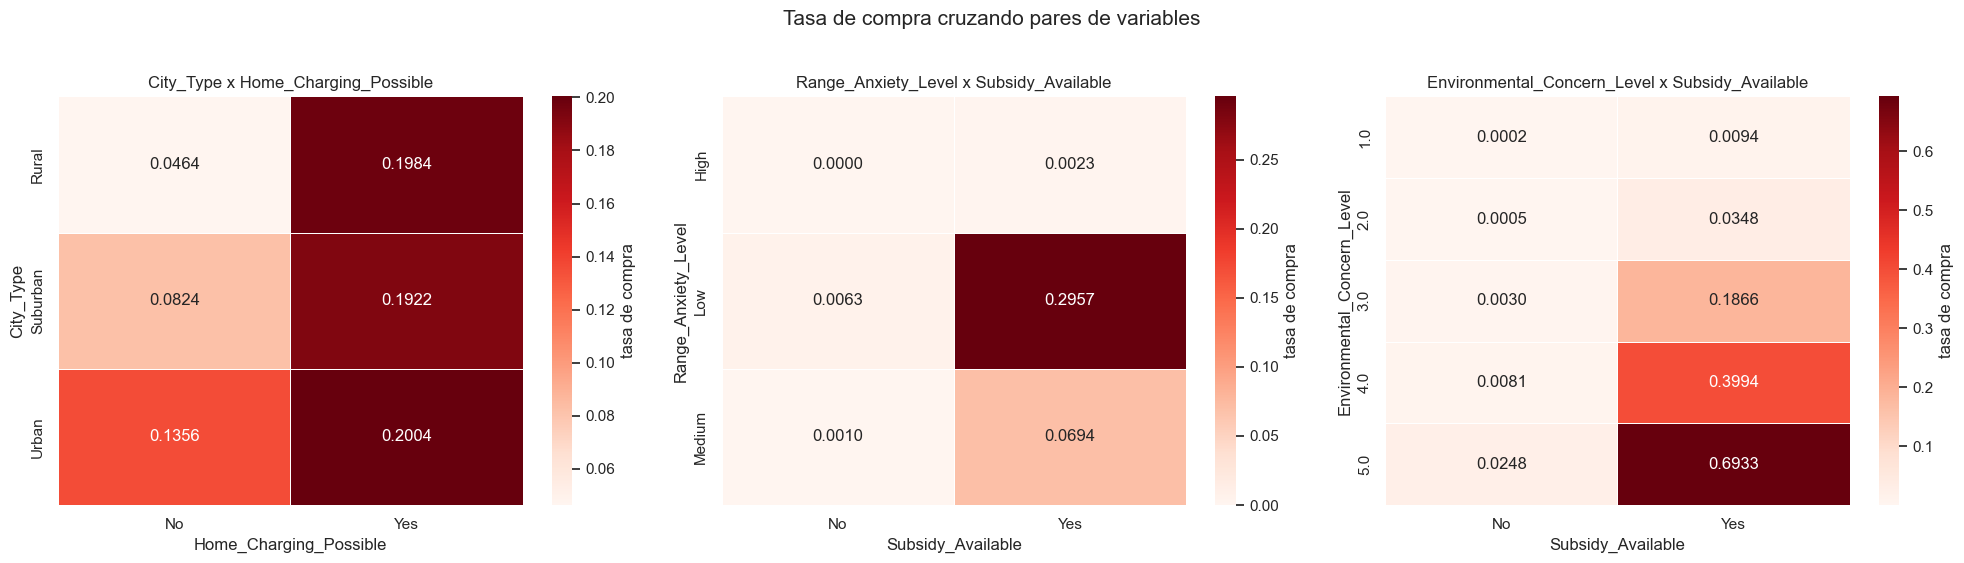

In [13]:
pares = [("City_Type", "Home_Charging_Possible"),
         ("Range_Anxiety_Level", "Subsidy_Available"),
         ("Environmental_Concern_Level", "Subsidy_Available")]

fig, axes = plt.subplots(1, 3, figsize=(20, 5.5))
for ax, (a, b) in zip(axes, pares):
    piv = train.pivot_table(index=a, columns=b, values="y", aggfunc="mean")
    sns.heatmap(piv, annot=True, fmt=".4f", cmap="Reds", ax=ax,
                linewidths=0.5, linecolor="white", cbar_kws={"label": "tasa de compra"})
    ax.set_title(f"{a} x {b}")
plt.suptitle("Tasa de compra cruzando pares de variables", fontsize=15, y=1.02)
plt.tight_layout()
plt.show()

In [14]:
# Si el efecto fuera aditivo en log-odds, la diferencia entre columnas seria constante por fila.
# Las celdas con muy pocos positivos dan log-odds inestables, asi que se marcan y se excluyen
# del veredicto en lugar de dejar que dominen el rango.
MIN_POS = 20

for a, b in pares:
    tasa = train.pivot_table(index=a, columns=b, values="y", aggfunc="mean")
    pos  = train.pivot_table(index=a, columns=b, values="y", aggfunc="sum")
    lo   = np.log(tasa.clip(1e-6, 1 - 1e-6) / (1 - tasa.clip(1e-6, 1 - 1e-6)))
    dif  = (lo.iloc[:, 1] - lo.iloc[:, 0]).round(3)
    solido = (pos >= MIN_POS).all(axis=1)

    print(f"{a} x {b}")
    print(f"  delta log-odds ({tasa.columns[1]} vs {tasa.columns[0]}) por fila: {dif.to_dict()}")
    if (~solido).any():
        flojas = {i: int(pos.loc[i].min()) for i in pos.index[~solido]}
        print(f"  filas descartadas por tener menos de {MIN_POS} positivos en alguna celda: {flojas}")
    d = dif[solido]
    if len(d) < 2:
        print("  quedan menos de 2 filas solidas: no se puede juzgar la aditividad\n")
        continue
    rango = d.max() - d.min()
    print(f"  rango del delta sobre las {len(d)} filas solidas: {rango:.3f}"
          f"   -> {'INTERACCION' if rango > 0.6 else 'aproximadamente aditivo'}\n")

City_Type x Home_Charging_Possible
  delta log-odds (Yes vs No) por fila: {'Rural': 1.627, 'Suburban': 0.975, 'Urban': 0.468}
  rango del delta sobre las 3 filas solidas: 1.159   -> INTERACCION



Range_Anxiety_Level x Subsidy_Available
  delta log-odds (Yes vs No) por fila: {'High': 7.741, 'Low': 4.189, 'Medium': 4.323}
  filas descartadas por tener menos de 20 positivos en alguna celda: {'High': 0}
  rango del delta sobre las 2 filas solidas: 0.134   -> aproximadamente aditivo



Environmental_Concern_Level x Subsidy_Available
  delta log-odds (Yes vs No) por fila: {1.0: 4.035, 2.0: 4.293, 3.0: 4.324, 4.0: 4.401, 5.0: 4.489}
  filas descartadas por tener menos de 20 positivos en alguna celda: {1.0: 10}
  rango del delta sobre las 4 filas solidas: 0.196   -> aproximadamente aditivo



**`City_Type` x `Home_Charging_Possible` es una interacción genuina**: sin posibilidad de cargar en
casa la tasa va de 4,6 % en Rural a 13,6 % en Urban, pero cuando sí se puede cargar las tres zonas se
emparejan en ~19-20 %. En log-odds, el efecto de poder cargar en casa vale +1,63 en Rural y sólo
+0,47 en Urban. Tiene sentido: la ciudad importa mientras dependas de la red pública, y deja de
importar cuando cargás en tu casa. Vale la pena cruzarlas explícitamente para el logit.

Los otros dos cruces son **aditivos en log-odds** una vez que se descarta la celda degenerada de
`Range_Anxiety = High` con `Subsidy = No` (887 filas y **cero** positivos, log-odds no estimable):
entre `Low` y `Medium` el efecto del subsidio es prácticamente el mismo (+4,19 vs +4,32), y a lo
largo de los cinco niveles de concern se mueve apenas de +4,04 a +4,49. Ahí cruzar no debería aportar
casi nada.

## 9. Correlaciones

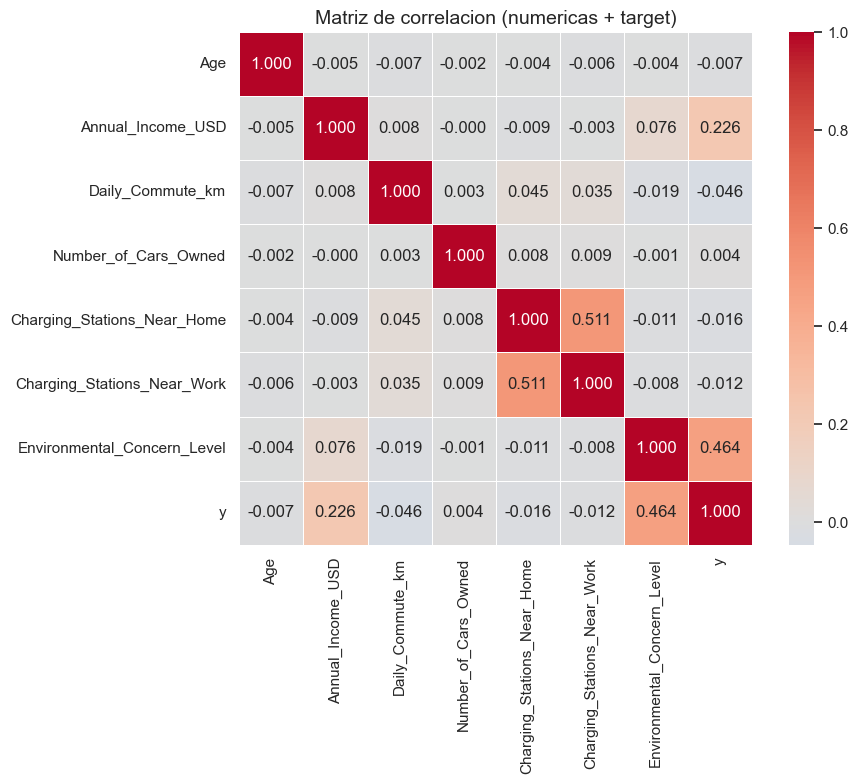

Correlacion de cada numerica con el target:
Environmental_Concern_Level    0.4641
Annual_Income_USD              0.2257
Daily_Commute_km              -0.0459
Charging_Stations_Near_Home   -0.0164
Charging_Stations_Near_Work   -0.0122
Age                           -0.0074
Number_of_Cars_Owned           0.0039


In [15]:
cols_corr = numericas + ["y"]
corr = train[cols_corr].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(corr, annot=True, fmt=".3f", cmap="coolwarm", center=0, ax=ax,
            linewidths=0.5, linecolor="white", square=True)
ax.set_title("Matriz de correlacion (numericas + target)", fontsize=14)
plt.tight_layout()
plt.show()

print("Correlacion de cada numerica con el target:")
print(corr["y"].drop("y").sort_values(key=abs, ascending=False).round(4).to_string())

Las numéricas son **mutuamente independientes** (correlaciones entre ellas por debajo de 0,01): es un
dataset sintético sin colinealidad, así que los coeficientes del logit van a ser interpretables de a
uno.

## 10. Conclusiones

- **Dataset impecable**: 668.665 × 15, cero nulos en train y test, cero filas duplicadas, ids únicos.
  No hace falta imputar nada; todo el trabajo va a estar en la representación de las features.
- **Desbalance moderado** (17,46 % de positivos, 1 cada 4,73). Con ROC AUC no hay que rebalancear.
- **La señal está concentrada en dos variables**: `Environmental_Concern_Level` sola rinde
  **AUC 0,8435** (la tasa va de 0,57 % en el nivel 1 a 51,83 % en el 5) y `Annual_Income_USD` 0,6704.
  Entre las categóricas, `Subsidy_Available` llega a 0,7179 — sin subsidio la tasa se derrumba a
  0,58 % contra 27,47 % con subsidio.
- **Casi la mitad de las columnas son ruido**: `Age` (0,5055), `Number_of_Cars_Owned` (0,5039),
  `Gender` (0,5046), `Current_Car_Type` (0,5104) y los dos conteos de estaciones (0,51-0,52) están
  pegados al azar. Conviene dejarlas en el modelo por si aportan en combinación, pero no esperar nada
  de ellas por separado.
- **Las numéricas son mutuamente independientes** (correlaciones entre ellas por debajo de 0,01, como
  corresponde a un dataset sintético): sin colinealidad, los coeficientes del logit se van a poder
  leer de a uno.
- **La forma favorece a un modelo lineal.** `Environmental_Concern_Level` es monótona con saltos de
  log-odds parejos (1,0-1,7 por nivel). `Annual_Income_USD` también es monótona pero más empinada en
  los deciles bajos (+0,69 del primero al segundo vs ~0,15-0,25 en el medio), así que `log(ingreso)`
  es una transformación con fundamento.
- **Hay una interacción real y una sola**: `City_Type` × `Home_Charging_Possible`. Poder cargar en
  casa vale +1,63 de log-odds en Rural pero sólo +0,47 en Urban — la zona importa mientras dependas
  de la red pública. Es lo único que un logit aditivo no puede representar, y por eso entra como
  feature cruzada.
- **Los otros cruces no aportan**: el efecto de `Subsidy_Available` es estable a lo largo de
  `Range_Anxiety_Level` (+4,19 vs +4,32 entre `Low` y `Medium`) y de `Environmental_Concern_Level`
  (+4,04 a +4,49). El único desvío aparente venía de una celda con 887 filas y cero positivos, no de
  una interacción.
- **Próximo paso**: `2_logit.ipynb` — baseline lineal con las crudas, `log(ingreso)` y el cruce
  `City_Type` × `Home_Charging_Possible`, validado con `StratifiedKFold(5)` sobre ROC AUC. El piso a
  superar es 0,8435 (la mejor variable sola) y la referencia de arriba es el tope actual del
  leaderboard, 0,94631.